We import the necessary modules

In [1]:
using JuMag
using Printf
using NPZ

We use the double float precision in the simulation

In [2]:
JuMag.cuda_using_double(true)

The geometry of the studied system is a film of thickness t=3 nm, length L=500 nm and width d=125 nm.

In [3]:
mesh =  FDMeshGPU(nx=200, ny=50, nz=1, dx=2.5e-9, dy=2.5e-9, dz=3e-9)

FDMeshGPU{Float64}(2.5e-9, 2.5e-9, 3.0e-9, 200, 50, 1, 10000, false, false, false, 1.8750000000000001e-26)

The first step is to relax the system, after which we should obtain a 'S' state.

In [4]:
function relax_system(mesh)
  #Create a simulation with 'SD' driver
  sim = Sim(mesh, name="std4_relax", driver="SD")

  set_Ms(sim, 8.0e5)
  sim.driver.min_tau = 1e-10

  add_exch(sim, 1.3e-11)
  add_demag(sim)

  init_m0(sim, (1, 0.25, 0.1))

  relax(sim, maxsteps=5000, stopping_dmdt=0.01)
  npzwrite("std4_m0.npy", Array(sim.spin))
end

relax_system (generic function with 1 method)

The second step is to apply an external field starting from the obtained 'S' state in previous step.

In [5]:
function apply_field1(mesh)
  sim = Sim(mesh, name="std4")
  set_Ms(sim, 8.0e5)
  sim.driver.alpha = 0.02
  sim.driver.gamma = 2.211e5

  mT = 0.001 / (4*pi*1e-7)
  add_exch(sim, 1.3e-11)
  add_demag(sim)
  add_zeeman(sim, (-24.6*mT, 4.3*mT, 0))

  init_m0(sim, npzread("std4_m0.npy"))

  for i=1:100
    t = 1e-11*i
    run_until(sim, t)
    @info @sprintf("Run step2 up to time %g", t)
  end
end

apply_field1 (generic function with 1 method)

Run the steps 1 and 2.

In [6]:
if !isfile("std4_m0.npy")
  relax_system(mesh)
end
if !isfile("std4_llg.txt")
  apply_field1(mesh)
end

Finally, we plot the time evolution of the magnetization using the plot_m function

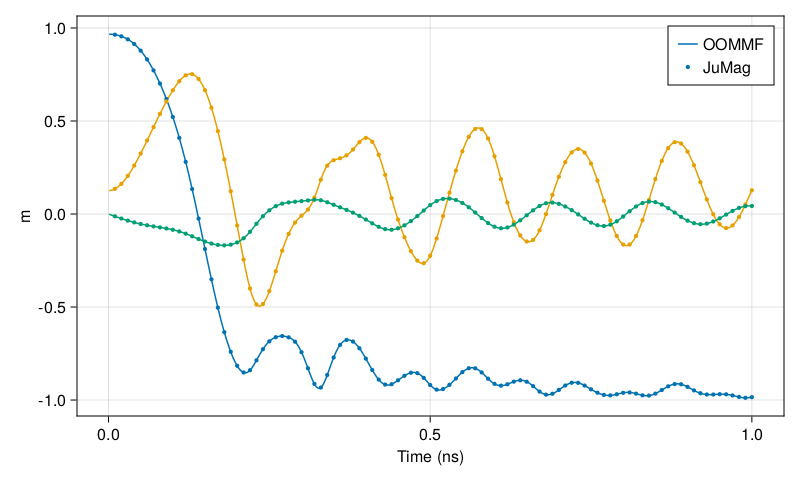

In [7]:
using DelimitedFiles
using CairoMakie

function plot_m()
    folder = @__DIR__
    data = readdlm("std4_llg.txt", skipstart=2)
    oommf = readdlm("assets/std4_oommf.txt")

    fig = Figure(resolution = (800, 480))
    ax = Axis(fig[1, 1],
        xlabel = "Time (ns)",
        ylabel = "m"
    )

    lines!(ax, oommf[:,1]*1e9, oommf[:,2], label="OOMMF")
    lines!(ax, oommf[:,1]*1e9, oommf[:,3])
    lines!(ax, oommf[:,1]*1e9, oommf[:,4])

    scatter!(ax, data[:,2]*1e9, data[:,4], markersize = 6, label="JuMag")
    scatter!(ax, data[:,2]*1e9, data[:,5], markersize = 6)
    scatter!(ax, data[:,2]*1e9, data[:,6], markersize = 6)

    axislegend()

    return fig

end

plot_m()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*